## Task 3: Denoising Diffusion Model for Jet Reconstruction

In this notebook we build a **Denoising Diffusion Probabilistic Model (DDPM)** to reconstruct quark/gluon jet images.

Diffusion models work in two stages:
- **Forward process**: gradually add Gaussian noise to a clean image over T timesteps until it becomes pure noise
- **Reverse process**: train a neural network (U-Net) to predict and remove the noise step by step, restoring the original image.

The pipeline:

1. **Forward diffusion** — linear noise scheduler adds noise according to a β schedule
2. **U-Net architecture** — DownBlocks, MidBlock, UpBlocks with time embeddings and self-attention
3. **Training** — the model learns to predict the noise added at each timestep
4. **Reconstruction** — start from a lightly noised image and denoise back to the original
5. **Evaluation** — MSE and SSIM metrics on the test set


In [ ]:
import torch
import os
import torchvision.transforms as transforms
from PIL import Image

import math
import matplotlib.pyplot as plt
import h5py
import numpy as np
import gc

import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

from skimage.metrics import structural_similarity as ssim_metric

# -----------------------------
# CONFIG
# -----------------------------
h5_path = "/content/drive/MyDrive/ML4SCI/quark-gluon_data-set_n139306.hdf5"
subset_size = 50000
batch_size = 4
num_epochs = 5
lr = 1e-4
seed = 42

alpha_weight = 8.0
signal_threshold = 1e-6
t_start_recon = 5

torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

###  Forward Diffusion Process

#### β schedule

 β in DDPM is "how much noise to add". At the start (t=0) we start to add some noises to the image, and by the end (t=1000) the image is completely fullied in the noise. The β schedule controls this — we increase β slowly and linearly from a the value `1e-4` all the way up to `2e-2`  as mentioned in the paper

#### Forward process

 in The forward process we take a clean jet image and will add some noise (β) after *t* steps.

 shortcut formula that goes directly to any timestep t in one equation:
```
x_t = √ᾱ_t · x₀  +  √(1 - ᾱ_t) · ε,    ε ~ N(0, I)
```


In [ ]:
def Beta_schedule(time):
    b1 = 1e-4
    bt = 2e-2

    return (bt-b1)/1000 * time


def forwardprocess(image, time):
    """
    This function implements the forward pass of diffusion process, takes an image and adds noise to it.
    Bt comes from a schedule
    """

    alpha_bar = 1
    for t in range(time):
        alpha_bar = alpha_bar*(1-Beta_schedule(t))

    noisy_image = math.sqrt(alpha_bar)*image + math.sqrt(1-alpha_bar)*torch.randn_like(image)
    noise = noisy_image - image

    return noisy_image, noise

#### Linear Noise Scheduler

`Linear_Noise_Scheduler` precomputes all the quantities needed for both the forward and reverse processes:

| Attribute | Formula | Purpose |
|---|---|---|
| `betas` | linear from β₁ to βT | the β values from `1e-4` to `2e-2` |
| `alpha` | `1 - beta` | just 1 - beta at each step |
| `alpha_cumulative_prod` (ᾱ) | `cumprod(alpha)` | running product of all alphas, tells us how much signal is left at step t |
| `sqrt_alpha_cumulative_prod` | `√ᾱ` | scales the clean image in the forward equation |
| `sqrt_one_minus_alpha_cumulative_prod` | `√(1-ᾱ)` | scales the noise in the forward equation |

`add_noise` applies the forward process to jump to any timestep t in one shot. `sample_prev_timestep` takes the model's predicted noise and steps one step backward in the reverse process.

In [ ]:
class Linear_Noise_Scheduler:
  def __init__(self, num_timesteps= 1000, B_start= 1e-4, B_last = 2e-2, device='cpu'):
    """
    Args:
      num_timestep: this is the time steps from the paper
      B_start: first beta of the Noise Scheduler
      B_last: last beta of the Noise Scheduler
      device: The device to store the scheduler's tensors
    """

    self.num_timesteps = num_timesteps
    self.B_start = B_start
    self.B_last = B_last

    self.betas = torch.linspace(start= B_start, end = B_last, steps = num_timesteps).to(device)
    self.alpha = 1 - self.betas

    self.alpha_cumulative_prod = torch.cumprod(self.alpha, dim = 0).to(device)
    self.sqrt_alpha_cumulative_prod = torch.sqrt(self.alpha_cumulative_prod)
    self.sqrt_minus_alpha_cumulative_prod = torch.sqrt(1 -  self.alpha_cumulative_prod)

  def add_noise(self, original, noise, t):
    original_shape = original.shape
    batch_size = original_shape[0]

    # grab the scheduler values for the given timesteps
    sqrt_alpha_cumulative_prod = self.sqrt_alpha_cumulative_prod[t].reshape(batch_size)
    sqrt_minus_alpha_cumulative_prod = self.sqrt_minus_alpha_cumulative_prod[t].reshape(batch_size)

    # expand from [B] to [B, 1, 1, 1] so we can multiply with the image tensor
    for _ in range(len(original_shape) - 1):
        sqrt_alpha_cumulative_prod = sqrt_alpha_cumulative_prod.unsqueeze(-1)
        sqrt_minus_alpha_cumulative_prod = sqrt_minus_alpha_cumulative_prod.unsqueeze(-1)

    # forward diffusion: x_t = sqrt(at)*x_0 + sqrt(1-at)*noise
    return sqrt_alpha_cumulative_prod * original + sqrt_minus_alpha_cumulative_prod * noise


  def sample_prev_timestep(self, xt, noise_pred, t):
    # get the scheduler values at the current timestep t
    sqrt_one_minus_alpha_cum_prod_t = self.sqrt_minus_alpha_cumulative_prod[t]
    sqrt_alpha_cumulative_prod_t = self.sqrt_alpha_cumulative_prod[t]
    betas_t = self.betas[t]
    alpha_t = self.alpha[t]

    # expand all to [B, 1, 1, 1] to broadcast correctly with image tensors [B, C, H, W]
    num_spatial_dims = len(xt.shape) - 1

    for _ in range(num_spatial_dims):
        sqrt_one_minus_alpha_cum_prod_t = sqrt_one_minus_alpha_cum_prod_t.unsqueeze(-1)
        sqrt_alpha_cumulative_prod_t = sqrt_alpha_cumulative_prod_t.unsqueeze(-1)
        betas_t = betas_t.unsqueeze(-1)
        alpha_t = alpha_t.unsqueeze(-1)

    # estimate x0 from the current noisy image and the predicted noise
    x0 = (xt - (sqrt_one_minus_alpha_cum_prod_t * noise_pred)) / sqrt_alpha_cumulative_prod_t
    x0 = torch.clamp(x0, -1., 1.)

    # compute the mean of the reverse distribution q(x_{t-1} | x_t, x_0)
    mean = xt - ((betas_t * noise_pred) / sqrt_one_minus_alpha_cum_prod_t)
    mean = mean / torch.sqrt(alpha_t)

    # if we reached t=0 return the mean directly, no noise needed
    if (t == 0).all():
        return mean, x0
    else:
        # compute the posterior variance and sample from it
        alpha_cum_prod_t = self.alpha_cumulative_prod[t]
        alpha_cum_prod_t_minus_1 = self.alpha_cumulative_prod[t-1]

        for _ in range(num_spatial_dims):
            alpha_cum_prod_t = alpha_cum_prod_t.unsqueeze(-1)
            alpha_cum_prod_t_minus_1 = alpha_cum_prod_t_minus_1.unsqueeze(-1)

        variance = (1. - alpha_cum_prod_t_minus_1) / (1. - alpha_cum_prod_t)
        variance = variance * betas_t
        sigma = variance ** 0.5

        # add scaled random noise to get x_{t-1}
        z = torch.randn(xt.shape).to(xt.device)
        return mean + sigma * z, x0

### 2. U-Net Architecture

The backbone of the diffusion model is a **U-Net** with three types of blocks. The U-Net takes a noisy image `x_t` and the current timestep `t` as inputs, and outputs the predicted noise `ε_θ(x_t, t)`.

#### Time embedding

The timestep `t` needs to be passed to every layer in the network so it knows "how noisy" the input is. We encode it as a fixed-size vector using `sinusoidal functions`,  the same idea as positional encodings in Transformers:
```python
t_emb = [sin(t / 10000^(2i/d)), cos(t / 10000^(2i/d))]  for i in range(d//2)
```

This vector is then passed into each block via a small linear layer.

#### DownBlock

Each `DownBlock` does four things:
1. **ResNet-style convolution**: two conv layers with GroupNorm + SiLU, with a skip connection to avoid vanishing gradients
2. **Time injection**: projects the time embedding to match the channel dimension and adds it to the feature map
3. **Self-attention**: lets the model look at the whole feature map at once, useful for capturing the global structure of the jet
4. **Optional downsampling**: halves the spatial resolution with a strided conv when `down_sample=True`

In [ ]:
from torch import nn
def get_time_embedding(time_steps, t_emb_dim):
    half_dim = t_emb_dim // 2
    exponent = torch.arange(half_dim, device=time_steps.device).float() / half_dim
    factor = 10000 ** exponent
    t_emb = time_steps[:, None].float() / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=-1)
    return t_emb

class DownBlock(nn.Module):
  def __init__(self, in_channels, out_channels, t_emb_dim, down_sample, num_heads):
        super().__init__()
        self.down_sample = down_sample
        self.resnet_conv_first = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        )
        self.t_emb_layers = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, out_channels)
        )
        self.resnet_conv_second = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        )
        self.attention_norm = nn.GroupNorm(8, out_channels)
        self.attention = nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
        self.residual_input_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.down_sample_conv = nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1) if self.down_sample else nn.Identity()

  def forward(self, x, t_emb):
    out = self.resnet_conv_first(x)
    out = out + self.t_emb_layers(t_emb)[:, :, None, None]
    out = self.resnet_conv_second(out)
    out = out + self.residual_input_conv(x)

    batch_size, channels, h, w = out.shape
    if h <= 16:
        in_attn = out.reshape(batch_size, channels, h * w)
        in_attn = self.attention_norm(in_attn).transpose(1, 2)
        out_attn, _ = self.attention(in_attn, in_attn, in_attn)
        out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
        out = out + out_attn

    out = self.down_sample_conv(out)
    return out

#### MidBlock

The `MidBlock` sits at the **bottleneck** of the U-Net — the lowest resolution, highest channel count layer. It applies two ResNet convolutions with a self-attention layer in between:

```
ResNet conv → Self-Attention → ResNet conv
```

This is where the model builds the most abstract, global representation of the jet before the decoder starts upsampling. The attention here is especially important because it can relate distant parts of the jet to each other.


In [ ]:
import torch.nn as nn

class MidBlock(nn.Module):
  def __init__(self, in_channels, out_channels, t_emb_dim, num_heads):
    super().__init__()

        # Two ResNet-style convolution sequences
    self.resnet_conv_first = nn.ModuleList([
            nn.Sequential(
                nn.GroupNorm(8, in_channels),
                nn.SiLU(),
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
            ),
            nn.Sequential(
                nn.GroupNorm(8, out_channels),
                nn.SiLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
            )
        ])

        # Two time embedding projection layers
    self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            ),
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
        ])

        # Two secondary ResNet convolution sequences
    self.resnet_conv_second = nn.ModuleList([
            nn.Sequential(
                nn.GroupNorm(8, out_channels),
                nn.SiLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
            ),
            nn.Sequential(
                nn.GroupNorm(8, out_channels),
                nn.SiLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
            )
        ])

    self.attention_norm = nn.GroupNorm(8, out_channels)
    self.attention = nn.MultiheadAttention(out_channels, num_heads, batch_first=True)

        # Residual connections to handle potential channel dimension shifts
    self.residual_input_conv = nn.ModuleList([
    nn.Conv2d(in_channels, out_channels, kernel_size=1),
    nn.Conv2d(out_channels, out_channels, kernel_size=1)
      ])

  def forward(self, x, t_emb):
    out = x

    #  First ResNet Block
    resnet_input = out
    out = self.resnet_conv_first[0](out)
    # Inject time embedding for the first stage of the bottleneck
    out = out + self.t_emb_layers[0](t_emb)[:, :, None, None]
    out = self.resnet_conv_second[0](out)
    out = out + self.residual_input_conv[0](resnet_input)

    #  Attention Block
    batch_size, channels, h, w = out.shape
    # Flatten spatial dimensions: [B, C, H, W] -> [B, C, H*W]
    in_attn = out.reshape(batch_size, channels, h * w)
    in_attn = self.attention_norm(in_attn)
    # Prepare for MultiheadAttention: [B, Seq_Len, Channels]
    in_attn = in_attn.transpose(1, 2)

    out_attn, _ = self.attention(in_attn, in_attn, in_attn)

    # Restore spatial dimensions: [B, Seq_Len, Channels] -> [B, C, H, W]
    out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
    out = out + out_attn

    # Second ResNet Block
    resnet_input = out
    out = self.resnet_conv_first[1](out)
    # Inject time embedding for the second stage of the bottleneck
    out = out + self.t_emb_layers[1](t_emb)[:, :, None, None]
    out = self.resnet_conv_second[1](out)
    out = out + self.residual_input_conv[1](resnet_input)

    return out

#### UpBlock

Each `UpBlock` mirrors a `DownBlock` but in reverse — it builds the image back up:
1. **Optional upsampling** — doubles the spatial resolution using bilinear interpolation
2. **ResNet conv + time injection** — same structure as the DownBlock
3. **Self-attention** — re-attends to the spatial structure at the new resolution
4. **Skip connection from encoder** — features from the matching DownBlock are concatenated before the conv, so the decoder can recover fine details that were lost during downsampling

The skip connections are what make this a U-Net without them the decoder only has the compressed bottleneck to work from, and a lot of spatial detail would be lost.

In [ ]:
class UpBlock(nn.Module):
  def __init__(self, in_channels, out_channels, t_emb_dim, up_sample, num_heads):
        super().__init__()
        self.up_sample = up_sample
        self.resnet_conv_first = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        )
        self.t_emb_layers = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, out_channels)
        )
        self.resnet_conv_second = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        )
        self.attention_norm = nn.GroupNorm(8, out_channels)
        self.attention = nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
        self.residual_input_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.up_sample_conv = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=4, stride=2, padding=1) if self.up_sample else nn.Identity()

  def forward(self, x, out_down, t_emb):
    x = self.up_sample_conv(x)
    x = torch.cat([x, out_down], dim=1)
    out = self.resnet_conv_first(x)
    out = out + self.t_emb_layers(t_emb)[:, :, None, None]
    out = self.resnet_conv_second(out)
    out = out + self.residual_input_conv(x)

    batch_size, channels, h, w = out.shape
    if h <= 16: # Only apply attention at low resolutions to save memory
        in_attn = out.reshape(batch_size, channels, h * w)
        in_attn = self.attention_norm(in_attn).transpose(1, 2)
        out_attn, _ = self.attention(in_attn, in_attn, in_attn)
        out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
        out = out + out_attn
    return out

#### U-Net (full model)

`Unet` puts everything together. It takes the noisy image `x_t` and the timestep `t`, and outputs the predicted noise with the same shape as the input:
```
Input (x_t, t)
    ↓
Conv2d stem (3 → 16)
    ↓
DownBlock(16→32, downsample)
DownBlock(32→64, downsample)
DownBlock(64→128, no downsample)
    ↓
MidBlock(128→128→64)
    ↓
UpBlock(64→64, upsample) 
UpBlock(64→32, upsample) 
UpBlock(32→16, no upsample) 
    ↓
GroupNorm + SiLU + Conv2d (16 → 3)
    ↓
Output: predicted noise ε_θ(x_t, t), shape (batch, 3, 128, 128)
```


In [ ]:
class Unet(nn.Module):
    """
    Unet model comprising
    Down blocks, Midblocks and Uplocks
    """
    def __init__(self, model_config):
        super().__init__()
        im_channels = model_config['im_channels']
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.t_emb_dim = model_config['time_emb_dim']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']

        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-2]
        assert len(self.down_sample) == len(self.down_channels) - 1

        # Initial projection from sinusoidal time embedding
        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        self.up_sample = list(reversed(self.down_sample))
        self.conv_in = nn.Conv2d(im_channels, self.down_channels[0], kernel_size=3, padding=(1, 1))

        self.downs = nn.ModuleList([])
        for i in range(len(self.down_channels)-1):
            self.downs.append(DownBlock(self.down_channels[i], self.down_channels[i+1], self.t_emb_dim,
                                        down_sample=self.down_sample[i], num_heads=8))

        self.mids = nn.ModuleList([])
        for i in range(len(self.mid_channels)-1):
            self.mids.append(MidBlock(self.mid_channels[i], self.mid_channels[i+1], self.t_emb_dim,
                                      num_heads=8))

        self.ups = nn.ModuleList([])
        for i in reversed(range(len(self.down_channels)-1)):
            self.ups.append(UpBlock(self.down_channels[i] * 2, self.down_channels[i-1] if i != 0 else 16,
                                    self.t_emb_dim, up_sample=self.down_sample[i], num_heads=8))

        self.norm_out = nn.GroupNorm(8, 16)
        self.conv_out = nn.Conv2d(16, im_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        # Shapes that downblocks accepts are [C1, C2, C3, C4]
        # Shapes that midblocks accepts are [C4, C4, C3]
        # Shapes that downsamples accepts are [True, True, False]
        # B x C x H x W
        out = self.conv_in(x)
        # B x C1 x H x W

        # t_emb -> B x t_emb_dim
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        down_outs = []

        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)


        for mid in self.mids:
            out = mid(out, t_emb)
        # out B x C3 x H/4 x W/4

        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)
        
        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)
        # out = B x C x H x W
        return out

### Data Loading, Preprocessing and splitting

We load 50,000 jet events, preprocess Same two steps as in Task 1:
1. **Log normalisation** — compresses the wide energy range into `[0, 1]`
2. **Padding** — 125×125 → 128×128
3. **Split**: 80% train / 10% val / 10% test

In [ ]:
# load data
with h5py.File(h5_path, "r") as f:
    total_n = f["X_jets"].shape[0]
    N = total_n if subset_size is None else min(subset_size, total_n)
    X_jets = np.array(f["X_jets"][:N], dtype=np.float32)

print("Loaded data shape:", X_jets.shape)

Loaded data shape: (50000, 125, 125, 3)


In [ ]:
# preprocess the data
X = torch.tensor(X_jets, dtype=torch.float32).permute(0, 3, 1, 2)

# log transform for sparse detector images
scale = torch.tensor(50.0)
X = torch.log1p(X * scale) / torch.log1p(scale)

# pad 125 -> 128
X = F.pad(X, (1, 2, 1, 2))

print("Processed tensor shape:", X.shape)

dataset = TensorDataset(X)

# Split the data
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(seed)
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Processed tensor shape: torch.Size([50000, 3, 128, 128])
Train: 40000 Val: 5000 Test: 5000


In [ ]:
# Configering the model and move it to the device
model_config = {
    "im_channels": 3,
    "down_channels": [16, 32, 64, 128],
    "mid_channels": [128, 128, 64],
    "time_emb_dim": 128,
    "down_sample": [True, True, False],
    "num_down_layers": 1,
    "num_mid_layers": 1,
    "num_up_layers": 1,
}

model = Unet(model_config).to(device)
scheduler = Linear_Noise_Scheduler(num_timesteps=1000, device=device)
optimizer = optim.Adam(model.parameters(), lr=lr)


In [ ]:
# especial loss function to help giving the non-zero data more high values to get them appear in the model
def weighted_diffusion_loss(pred_noise, true_noise, x0, alpha=8.0, threshold=1e-6):
    weights = torch.ones_like(x0)
    weights[x0 > threshold] = alpha
    return (weights * (pred_noise - true_noise) ** 2).mean()

### Training Loop

We train for 5 epochs and save the best model

**Results:**

| Epoch | Train Loss | Val Loss |
|---|---|---|
| 1 | 0.035946 | 0.004720 |
| 2 | 0.003875 | 0.003129 |
| 3 | 0.002844 | 0.002265 |
| 4 | 0.002536 | 0.002405 |
| 5 | 0.002403 | 0.002601 |

The loss drops very sharply in epoch 1 (the model quickly learns to predict the broad noise pattern) then converges slowly. The best checkpoint is at epoch 3 where val loss is lowest (0.002265).


In [ ]:
def train_one_epoch():
    model.train()
    total_loss = 0.0

    for (x0,) in train_loader:
        x0 = x0.to(device)

        t = torch.randint(0, scheduler.num_timesteps, (x0.size(0),), device=device).long()
        noise = torch.randn_like(x0)

        xt = scheduler.add_noise(x0, noise, t)
        pred_noise = model(xt, t)

        loss = weighted_diffusion_loss(
            pred_noise,
            noise,
            x0,
            alpha=alpha_weight,
            threshold=signal_threshold
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x0.size(0)

    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = 0.0

    for (x0,) in val_loader:
        x0 = x0.to(device)

        t = torch.randint(0, scheduler.num_timesteps, (x0.size(0),), device=device).long()
        noise = torch.randn_like(x0)

        xt = scheduler.add_noise(x0, noise, t)
        pred_noise = model(xt, t)

        loss = weighted_diffusion_loss(
            pred_noise,
            noise,
            x0,
            alpha=alpha_weight,
            threshold=signal_threshold
        )

        total_loss += loss.item() * x0.size(0)

    return total_loss / len(val_loader.dataset)

In [ ]:
best_val_loss = float("inf")

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch()
    val_loss = evaluate()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "Denoising_diffusion_model.pth")

    print(f"Epoch {epoch}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")


Epoch 1/5 | Train Loss: 0.035946 | Val Loss: 0.004720
Epoch 2/5 | Train Loss: 0.003875 | Val Loss: 0.003129
Epoch 3/5 | Train Loss: 0.002844 | Val Loss: 0.002265
Epoch 4/5 | Train Loss: 0.002536 | Val Loss: 0.002405
Epoch 5/5 | Train Loss: 0.002403 | Val Loss: 0.002601


### Reverse Denoising (Reconstruction)

`reverse_denoise_from_timestep` reconstructs a jet image from a  noised image:

1. Take a clean image `x₀` and add a small amount of noise up to `t_start=5`
2. Run the reverse loop — at each step the U-Net predicts the noise and the scheduler removes it
3. Clamp the final output to `[0, 1]`

We use `t_start=5` instead of starting from pure noise (`t=1000`) because the model was only trained for 5 epochs. Starting from heavy noise would require a much longer training run for the model to recover the fine jet structure.

In [ ]:
model.load_state_dict(torch.load("Denoising_diffusion_model.pth", map_location=device))
model.eval()

# REVERSE DENOISING

@torch.no_grad()
def reverse_denoise_from_timestep(x0, t_start=5):
    model.eval()
    x0 = x0.to(device)

    t_batch = torch.full((x0.size(0),), t_start, dtype=torch.long, device=device)
    noise = torch.randn_like(x0)

    xt = scheduler.add_noise(x0, noise, t_batch)
    xt_start = xt.clone()

    for step in reversed(range(t_start + 1)):
        t_cur = torch.full((x0.size(0),), step, dtype=torch.long, device=device)
        noise_pred = model(xt, t_cur)

        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, t_cur)

    xt = torch.clamp(xt, 0.0, 1.0)
    return xt_start, xt

### Evaluation Metrics

We evaluate the reconstruction quality using two metrics:

- **MSE** (Mean Squared Error)
- **SSIM** (Structural Similarity Index)

In [ ]:
def mse_metric(x_true, x_pred):
    return ((x_true - x_pred) ** 2).mean().item()

def compute_ssim_batch(x_true, x_pred):
    x_true = x_true.cpu().numpy()
    x_pred = x_pred.cpu().numpy()

    scores = []
    for i in range(x_true.shape[0]):
        for c in range(x_true.shape[1]):
            score = ssim_metric(
                x_true[i, c],
                x_pred[i, c],
                data_range=float(x_true[i, c].max() - x_true[i, c].min() + 1e-8)
            )
            scores.append(score)

    return float(np.mean(scores))

### 10. Results

We run reconstruction on 3 test samples and compute the final metrics:

| Metric | Value |
|---|---|
| **MSE** | 0.000024 |
| **SSIM** | 0.740122 |

The very low MSE confirms pixel-level accuracy. The SSIM of 0.74 indicates good structural similarity, the model recovers the sparse energy patterns in all three detector channels (HCAL, ECAL, Tracks).


Final Reconstruction MSE  : 0.000024
Final Reconstruction SSIM : 0.740122


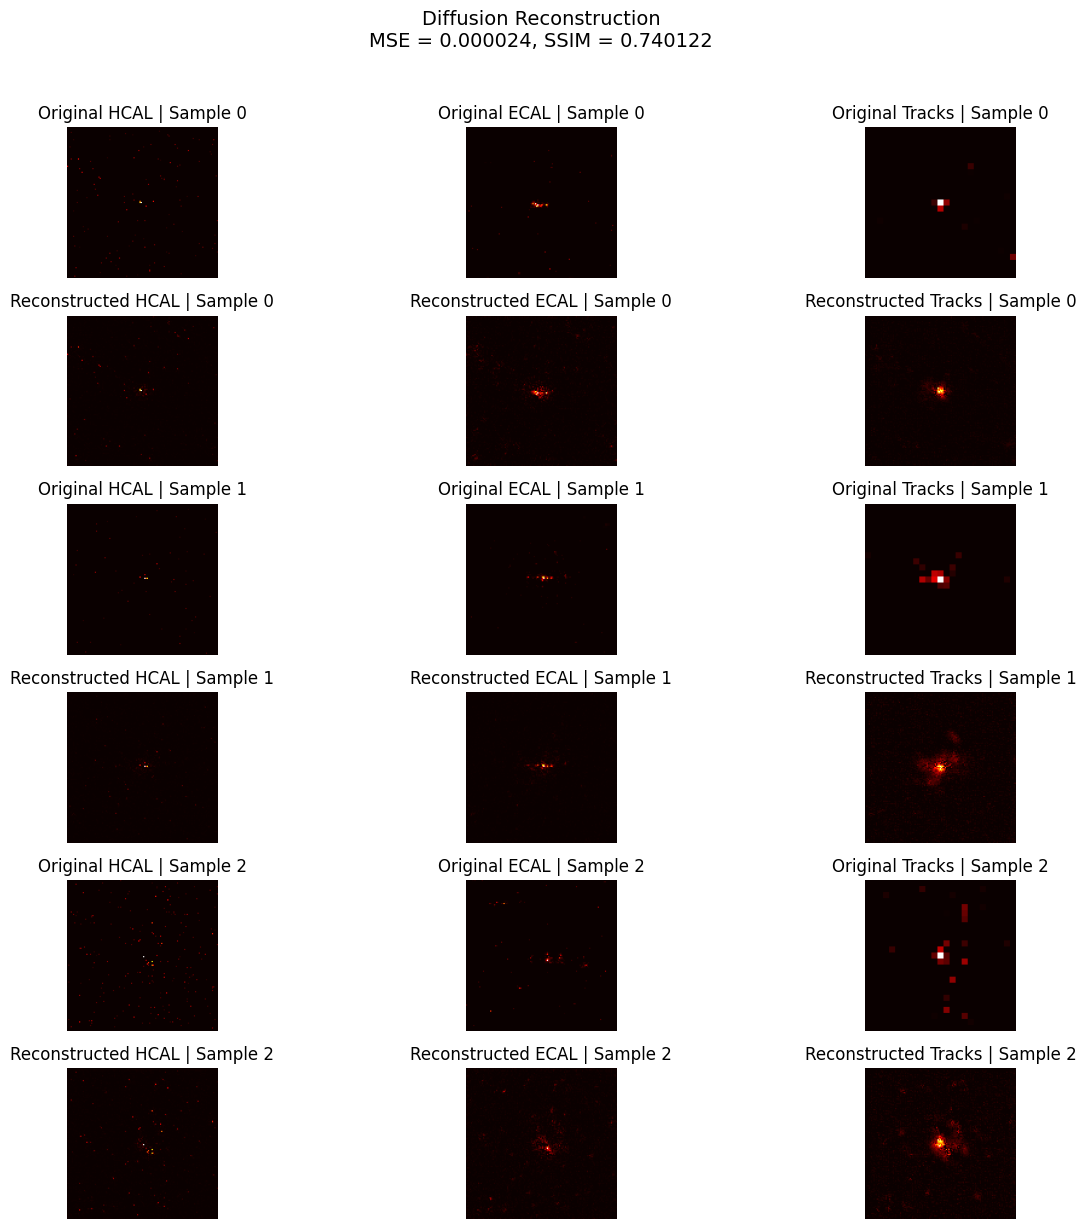

In [ ]:
x_batch = next(iter(test_loader))[0][:3]
_, recon_vis = reverse_denoise_from_timestep(x_batch, t_start=t_start_recon)

# remove padding back to 125x125
x_show = x_batch[:, :, 1:126, 1:126].cpu()
recon_show = recon_vis[:, :, 1:126, 1:126].cpu()

final_mse = mse_metric(x_show, recon_show)
final_ssim = compute_ssim_batch(x_show, recon_show)

print(f"Final Reconstruction MSE  : {final_mse:.6f}")
print(f"Final Reconstruction SSIM : {final_ssim:.6f}")

channel_names = ["HCAL", "ECAL", "Tracks"]
num_samples = x_show.shape[0]

fig, axes = plt.subplots(num_samples * 2, 3, figsize=(14, 4 * num_samples))

for s in range(num_samples):
    for c in range(3):
        axes[2*s, c].imshow(x_show[s, c], cmap="hot")
        axes[2*s, c].set_title(f"Original {channel_names[c]} | Sample {s}")
        axes[2*s, c].axis("off")

        axes[2*s + 1, c].imshow(recon_show[s, c], cmap="hot")
        axes[2*s + 1, c].set_title(f"Reconstructed {channel_names[c]} | Sample {s}")
        axes[2*s + 1, c].axis("off")

plt.suptitle(
    f"Diffusion Reconstruction\nMSE = {final_mse:.6f}, SSIM = {final_ssim:.6f}",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.show()